# Student Performance Prediction Using ANN

This notebook implements an Artificial Neural Network (ANN) to predict student grades based on various academic and lifestyle factors.

# Importing Essentials

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

## 1. Load Data

In [2]:
try:
    df = pd.read_csv('Students Performance Dataset.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: Dataset not found.")

Dataset loaded successfully.


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


## 2. Data Preprocessing

In [3]:
# Drop irrelevant columns
drop_cols = ['Student_ID', 'First_Name', 'Last_Name', 'Email']
df = df.drop(columns=drop_cols)

# Handle Missing Values
# Impute categorical columns with mode
categorical_cols_all = df.select_dtypes(include=['object']).columns
for col in categorical_cols_all:
    if df[col].isnull().sum() > 0:
        print(f"Imputing missing values for {col} with mode.")
        df[col] = df[col].fillna(df[col].mode()[0])

# Impute numerical columns with mean (if any)
numerical_cols_all = df.select_dtypes(include=['number']).columns
for col in numerical_cols_all:
    if df[col].isnull().sum() > 0:
        print(f"Imputing missing values for {col} with mean.")
        df[col] = df[col].fillna(df[col].mean())

Imputing missing values for Parent_Education_Level with mode.


C:\Users\Asus\AppData\Local\Temp\ipykernel_11116\2654828810.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_all = df.select_dtypes(include=['object']).columns


In [4]:
# Separate Features and Target
# We predict 'Grade'. We drop 'Total_Score' and 'Final_Score' to avoid data leakage 
# (assuming Grade is derived directly from them).
X = df.drop(columns=['Grade', 'Total_Score', 'Final_Score'])
y = df['Grade']

# Encode Categorical Features
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['number']).columns

# Use OneHotEncoder (get_dummies) for categorical inputs
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Encode Target (Grade)
le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(np.unique(y))

print("Classes:", le.classes_)

Classes: ['A' 'B' 'C' 'D' 'F']


C:\Users\Asus\AppData\Local\Temp\ipykernel_11116\1298070310.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


## 3. Train-Test Split & Scaling

In [5]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Numerical Features
scaler = StandardScaler()
# Fit on training data only to avoid leakage
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (4000, 21)
Test Data Shape: (1000, 21)


## 4. Build ANN Model

In [6]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # Regularization
    Dense(32, activation='relu'),
    Dropout(0.1), # Regularization
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\Asus\Desktop\Test\testenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,653 (14.27 KB)

 Trainable params: 3,653 (14.27 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train Model

In [7]:
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2, 
                    verbose=1)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4269 - loss: 1.3329 - val_accuracy: 0.5612 - val_loss: 1.0742
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5575 - loss: 1.0239 - val_accuracy: 0.5950 - val_loss: 0.9329
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5875 - loss: 0.9245 - val_accuracy: 0.6250 - val_loss: 0.8701
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6044 - loss: 0.8764 - val_accuracy: 0.6263 - val_loss: 0.8439
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6034 - loss: 0.8473 - val_accuracy: 0.6225 - val_loss: 0.8257
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6169 - loss: 0.8233 - val_accuracy: 0.6212 - val_loss: 0.8166
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6178 - loss: 0.8002 - val_accuracy: 0.6112 - val_loss: 0.8124
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6203 - loss: 0.7919 - val_accuracy: 0.

## 6. Evaluate Model

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 58.30%


## 7. Visualizations

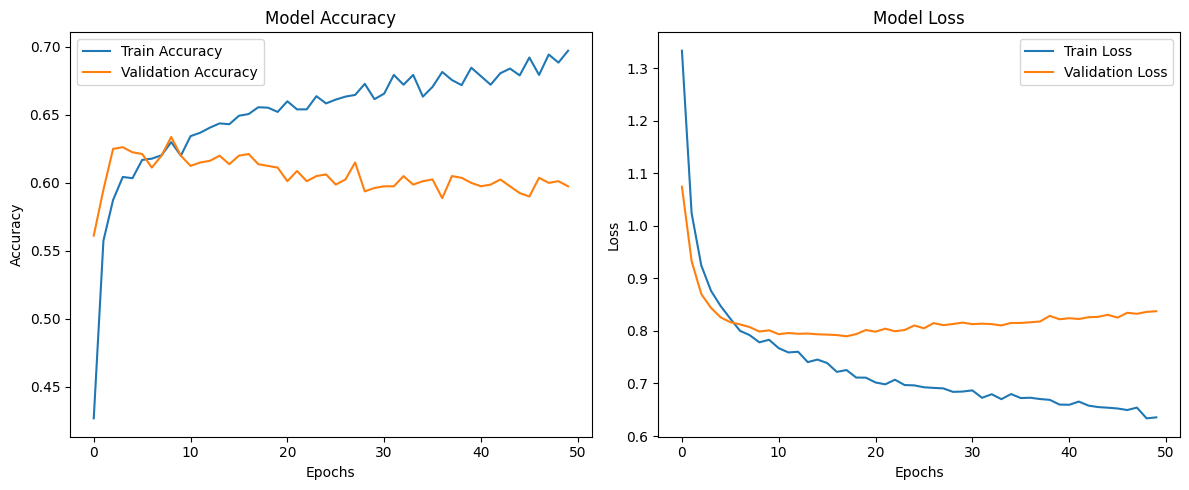

In [9]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Confusion Matrix & Report

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


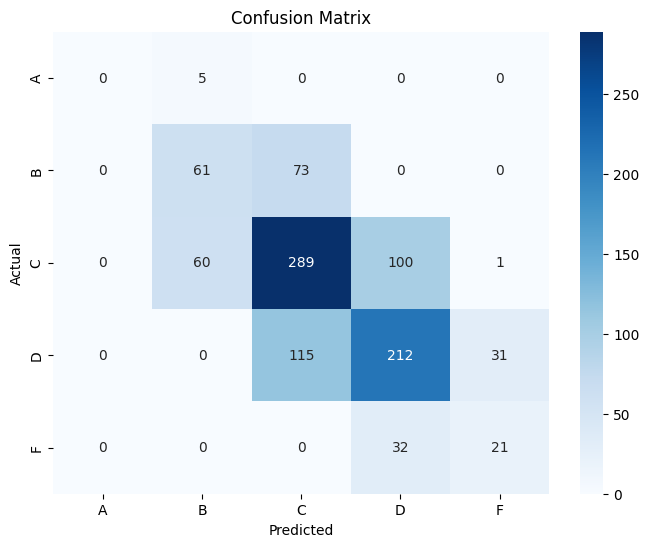


Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         5
           B       0.48      0.46      0.47       134
           C       0.61      0.64      0.62       450
           D       0.62      0.59      0.60       358
           F       0.40      0.40      0.40        53

    accuracy                           0.58      1000
   macro avg       0.42      0.42      0.42      1000
weighted avg       0.58      0.58      0.58      1000



C:\Users\Asus\Desktop\Test\testenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\Desktop\Test\testenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\Desktop\Test\testenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [10]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 9. Model Architecture

In [11]:
try:
    from tensorflow.keras.utils import plot_model
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print("Model architecture saved as 'model_architecture.png'")
    from IPython.display import Image
    display(Image('model_architecture.png'))
except Exception as e:
    print(f"Could not save/display model architecture plot: {e}")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as 'model_architecture.png'


FileNotFoundError: No such file or directory: 'model_architecture.png'

FileNotFoundError: No such file or directory: 'model_architecture.png'

<IPython.core.display.Image object>

In [12]:
!pip install IPython


In [13]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\Asus\Desktop\Test\testenv\pyrhon camp\projects\Major\project 2
['.ipynb_checkpoints', 'ann_model.py', 'check_categories.py', 'confusion_matrix.png', 'README.md', 'Students Performance Dataset.csv', 'student_performance_ann.ipynb', 'training_curves.png']


In [14]:
%pip install pydot graphviz



Note: you may need to restart the kernel to use updated packages.
